# PINNs pour l'équation de Schrödinger
## Électron dans un puits quantique GaAs/AlGaAs

**Système physique** : puits quantique GaAs de 10 nm  
**Problème direct** : résoudre l'équation de Schrödinger dépendante du temps  
**Problème inverse** : retrouver la masse effective $m^*$ à partir de mesures de $|\psi|^2$  

---

## 1. Imports et configuration

In [49]:
import torch
from torch.autograd import Variable
import torch.nn as nn
import numpy as np
from numpy import trapezoid
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import copy
import warnings
warnings.filterwarnings('ignore')

print("MPS disponible :", torch.mps.is_available())
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print("Device :", device)
torch.manual_seed(42)
np.random.seed(42)

MPS disponible : True
Device : mps


## 2. Constantes physiques et adimensionnement

### Système réel : électron dans un puits quantique GaAs/AlGaAs

On considère un puits de potentiel infini de largeur $L = 10\,\text{nm}$ dans du GaAs.
La masse effective de l'électron dans GaAs est $m^* = 0.067\,m_e$.

### Adimensionnement

On définit les échelles caractéristiques :
- $x_0 = L$ (longueur)  
- $E_0 = \hbar^2 / (m^* L^2)$ (énergie)  
- $t_0 = \hbar / E_0$ (temps)  

L'équation de Schrödinger $i\hbar\partial_t\psi = -\frac{\hbar^2}{2m^*}\partial_{xx}\psi + V\psi$ devient :

$$i\frac{\partial\psi}{\partial\tilde{t}} = -\frac{1}{2}\frac{\partial^2\psi}{\partial\tilde{x}^2} + \tilde{V}\psi$$

In [50]:
# --- Constantes physiques SI ---
hbar = 1.0546e-34    # J·s
m_e  = 9.109e-31     # kg
m_star = 0.067 * m_e # masse effective GaAs (kg)
L    = 10e-9          # largeur du puits (m)
eV   = 1.602e-19      # J/eV

# --- Échelles d'adimensionnement ---
E_0 = hbar**2 / (m_star * L**2)       # échelle d'énergie (J)
t_0 = hbar / E_0                       # échelle de temps (s)
x_0 = L                                # échelle de longueur (m)

E_0_meV = E_0 / eV * 1000
t_0_fs  = t_0 * 1e15
x_0_nm  = x_0 * 1e9


# On a fait un jolie print qui résume les données
print("="*60)
print("CONSTANTES PHYSIQUES DU PUITS QUANTIQUE GaAs")
print("="*60)
print(f"Largeur du puits      : L   = {x_0_nm:.1f} nm")
print(f"Masse effective       : m*  = {m_star/m_e:.3f} m_e = {m_star:.3e} kg")
print(f"Échelle d'énergie     : E_0 = {E_0_meV:.2f} meV")
print(f"Échelle de temps      : t_0 = {t_0_fs:.1f} fs")
print()

# --- Niveaux d'énergie (en unités réduites et physiques) ---
for n in range(1, 5):
    E_n_red = n**2 * np.pi**2 / 2  # unités réduites
    E_n_meV = E_n_red * E_0_meV    # meV
    print(f"E_{n} = {E_n_red:.3f} (réd.) = {E_n_meV:.1f} meV")

# Fréquence de battement entre n=1 et n=2
omega_21 = 3 * np.pi**2 / 2  # unités réduites
f_21_THz = omega_21 / (2 * np.pi * t_0) * 1e-12
T_beat_red = 2 * np.pi / omega_21
T_beat_fs = T_beat_red * t_0_fs
print(f"\nBattement 2-1 : ω₂₁ = {omega_21:.3f} (réd.)")
print(f"Période        : T_beat = {T_beat_red:.4f} (réd.) = {T_beat_fs:.1f} fs")
print(f"Fréquence      : f₂₁ = {f_21_THz:.1f} THz (infrarouge moyen)")

CONSTANTES PHYSIQUES DU PUITS QUANTIQUE GaAs
Largeur du puits      : L   = 10.0 nm
Masse effective       : m*  = 0.067 m_e = 6.103e-32 kg
Échelle d'énergie     : E_0 = 11.38 meV
Échelle de temps      : t_0 = 57.9 fs

E_1 = 4.935 (réd.) = 56.1 meV
E_2 = 19.739 (réd.) = 224.5 meV
E_3 = 44.413 (réd.) = 505.2 meV
E_4 = 78.957 (réd.) = 898.2 meV

Battement 2-1 : ω₂₁ = 14.804 (réd.)
Période        : T_beat = 0.4244 (réd.) = 24.6 fs
Fréquence      : f₂₁ = 40.7 THz (infrarouge moyen)


## 3. Solution analytique exacte (vérité terrain)

Pour le puits infini avec CI $\psi(x,0) = \frac{1}{\sqrt{2}}[\phi_1(x) + \phi_2(x)]$ :

$$\psi(x,t) = \frac{1}{\sqrt{2}}\left[\phi_1(x)\,e^{-iE_1 t} + \phi_2(x)\,e^{-iE_2 t}\right]$$

avec $\phi_n(x) = \sqrt{2}\sin(n\pi x)$ et $E_n = n^2\pi^2/2$.

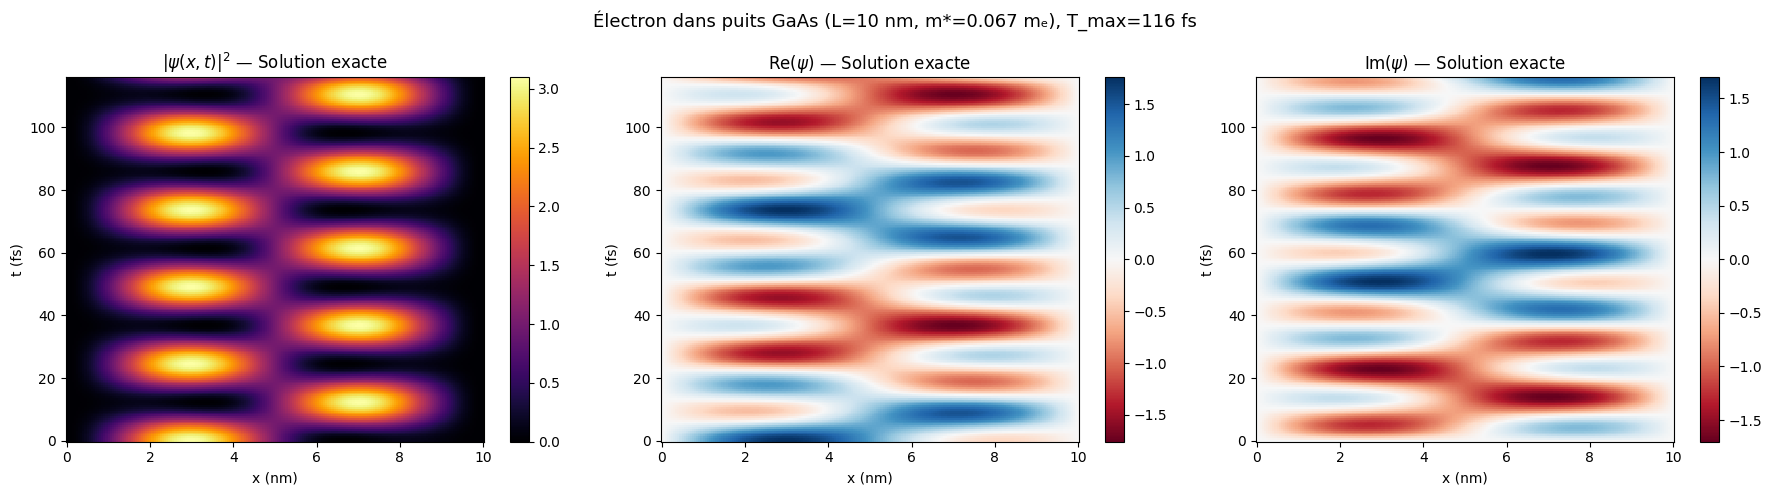

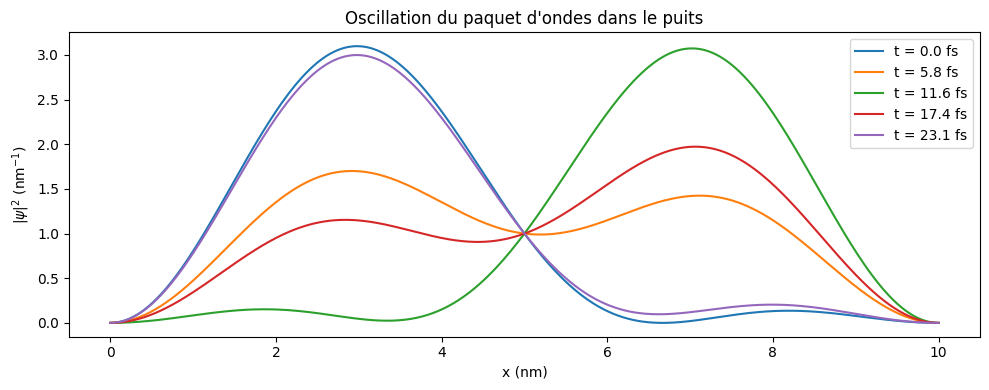

t = 0.0 (réd.) = 0.0 fs : ||psi||² = 1.000000
t = 0.5 (réd.) = 28.9 fs : ||psi||² = 1.000000
t = 1.0 (réd.) = 57.9 fs : ||psi||² = 1.000000
t = 1.5 (réd.) = 86.8 fs : ||psi||² = 1.000000
t = 2.0 (réd.) = 115.7 fs : ||psi||² = 1.000000


In [ ]:
def psi_exact(x, t):
    """Solution analytique en coordonnées adimensionnées.
    x, t : arrays numpy
    Retourne : psi (complexe), de même shape que x
    """
    phi1 = np.sqrt(2) * np.sin(np.pi * x)
    phi2 = np.sqrt(2) * np.sin(2 * np.pi * x)
    E1 = np.pi**2 / 2
    E2 = 2 * np.pi**2
    psi = (1/np.sqrt(2)) * (phi1 * np.exp(-1j * E1 * t) + phi2 * np.exp(-1j * E2 * t))
    return psi

def psi_exact_components(x, t):
    """Retourne (Re(psi), Im(psi)) séparément."""
    psi = psi_exact(x, t)
    return psi.real, psi.imag

# --- Visualisation de la solution analytique ---
Nx, Nt = 200, 200
T_max = 2.0  # en unités réduites 

x_grid = np.linspace(0, 1, Nx)
t_grid = np.linspace(0, T_max, Nt)
X, T_grid = np.meshgrid(x_grid, t_grid)
PSI = psi_exact(X, T_grid)
RHO = np.abs(PSI)**2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# |psi|^2
im0 = axes[0].pcolormesh(X * x_0_nm, T_grid * t_0_fs, RHO, cmap='inferno', shading='auto')
axes[0].set_xlabel('x (nm)')
axes[0].set_ylabel('t (fs)')
axes[0].set_title(r'$|\psi(x,t)|^2$ — Solution exacte')
plt.colorbar(im0, ax=axes[0])

# Re(psi)
im1 = axes[1].pcolormesh(X * x_0_nm, T_grid * t_0_fs, PSI.real, cmap='RdBu', shading='auto')
axes[1].set_xlabel('x (nm)')
axes[1].set_ylabel('t (fs)')
axes[1].set_title(r'Re($\psi$) — Solution exacte')
plt.colorbar(im1, ax=axes[1])

# Im(psi)
im2 = axes[2].pcolormesh(X * x_0_nm, T_grid * t_0_fs, PSI.imag, cmap='RdBu', shading='auto')
axes[2].set_xlabel('x (nm)')
axes[2].set_ylabel('t (fs)')
axes[2].set_title(r'Im($\psi$) — Solution exacte')
plt.colorbar(im2, ax=axes[2])

plt.suptitle(f'Électron dans puits GaAs (L={x_0_nm:.0f} nm, m*=0.067 mₑ), '
             f'
             
             
             
             
             ={T_max*t_0_fs:.0f} fs', fontsize=13)
plt.tight_layout()
plt.show()

# --- Coupe temporelle : oscillation du paquet d'ondes ---
fig, ax = plt.subplots(figsize=(10, 4))
x_plot = np.linspace(0, 1, 500)
for t_val in [0, 0.1, 0.2, 0.3, 0.4]:
    rho = np.abs(psi_exact(x_plot, t_val))**2
    ax.plot(x_plot * x_0_nm, rho, label=f't = {t_val*t_0_fs:.1f} fs')
ax.set_xlabel('x (nm)')
ax.set_ylabel(r'$|\psi|^2$ (nm$^{-1}$)')
ax.set_title('Oscillation du paquet d\'ondes dans le puits')
ax.legend()
plt.tight_layout()
plt.show()

# Vérification normalisation
for t_val in [0, 0.5, 1.0, 1.5, 2.0]:
    norm = np.trapezoid(np.abs(psi_exact(x_plot, t_val))**2, x_plot)
    print(f"t = {t_val:.1f} (réd.) = {t_val*t_0_fs:.1f} fs : ||psi||² = {norm:.6f}")

## 4. Définition du réseau de neurones

### Le problème initial

Le problème central : **ψ = 0 semble être une bonne solution**. Cette solution triviale satisfait :
- les CL : $\psi$(0,t) = $\psi$(1,t) = 0 (OK)
- l'EDP : i$\partial_t$(0) = -$\frac12 \partial_{xx}$(0) (OK)
- seule la CI s'y oppose, mais si elle est sous-pondérée, le réseau s'effondre vers 0 (la partie CI de la loss ne tire par assez vers une solution differente de 0)

### 4 idées pour que ça marche :

1. **Pré-train IC** ( itérations sur la CI solo) : ça peut forcer le réseau à d'abord apprendre $\psi$(x,0) $\neq$ 0
2. **λ_IC = 100**  la CI doit potentiellement dominer la loss au début
4. **Réseau plus large** (128×5 au lieu de 64×4) : plus d'expressivité pour capturer les oscillations (faire gaffe au sur-apprentissage quand même)


In [ ]:
class SchrodingerNet(nn.Module):
    """Réseau feed-forward pour approximer psi(x,t).
    Sortie : (Re(psi), Im(psi)) de dimension 2.
    
    Changements vs v1 :
    - 128 neurones (au lieu de 64) : ψ oscille, il faut plus d'expressivité
    - 5 couches cachées (au lieu de 4) : meilleure approximation des hautes fréquences
    """
    def __init__(self, hidden_dim=128, n_hidden=5, dropout_rate=0.0):
        super().__init__()
        layers = [nn.Linear(2, hidden_dim), nn.Tanh()]
        for _ in range(n_hidden - 1):
            if dropout_rate > 0:
                layers.append(nn.Dropout(p=dropout_rate))
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, 2))  # sortie (u, v) 
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        return self.net(inputs)

## 5. Définition du problème physique

Même structure que `forward_problem` du TP thermique : on définit les résidus de l'EDP, des CI et des CL.

**Résidus de l'EDP** (2 résidus couplés) :
- $r_{\text{Re}} = \partial_t u - \frac{\alpha}{2}\partial_{xx}v + Vv$
- $r_{\text{Im}} = \partial_t v + \frac{\alpha}{2}\partial_{xx}u - Vu$

Le paramètre $\alpha$ vaut 1 en problème direct. Pour le problème inverse, il devient apprenable.

In [53]:
class SchrodingerProblem:
    def __init__(self, net, alpha=1.0, alpha_trainable=False):
        self.net = net
        # alpha = 1 quand m* = m*_vrai. Pour le pb inverse, on l'apprend.
        if alpha_trainable:
            self.alpha = nn.Parameter(torch.tensor([alpha], dtype=torch.float32, device=device))
        else:
            self.alpha = torch.tensor([alpha], dtype=torch.float32, device=device)

    def ic_real(self, x):
        """Condition initiale : Re(psi(x, 0)) = (phi_1 + phi_2) / sqrt(2)"""
        phi1 = torch.sqrt(torch.tensor(2.0)) * torch.sin(np.pi * x)
        phi2 = torch.sqrt(torch.tensor(2.0)) * torch.sin(2 * np.pi * x)
        return (phi1 + phi2) / np.sqrt(2)

    def ic_imag(self, x):
        """Im(psi(x, 0)) = 0 (CI purement réelle)"""
        return torch.zeros_like(x)

    def residual(self, x, t):
        """Calcule les 2 résidus de l'EDP de Schrödinger.
        Exactement comme problem.f() dans le TP thermique, mais 2 résidus.
        """
        out = self.net(x, t)  # (N, 2)
        u = out[:, 0:1]  # Re(psi)
        v = out[:, 1:2]  # Im(psi)

        # Dérivées premières (comme u_x et u_t dans le TP)
        u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                                   retain_graph=True, create_graph=True)[0]
        v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v),
                                   retain_graph=True, create_graph=True)[0]
        u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u),
                                   retain_graph=True, create_graph=True)[0]
        v_t = torch.autograd.grad(v, t, grad_outputs=torch.ones_like(v),
                                   retain_graph=True, create_graph=True)[0]

        # Dérivées secondes (comme flux_x dans le TP)
        u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
                                    retain_graph=True, create_graph=True)[0]
        v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(v_x),
                                    retain_graph=True, create_graph=True)[0]

        # V(x) = 0 dans le puits infini
        # Résidus de i d_t psi = -alpha/2 d_xx psi
        # Re: d_t u = +alpha/2 * d_xx v
        # Im: d_t v = -alpha/2 * d_xx u
        r_re = u_t - (self.alpha / 2) * v_xx
        r_im = v_t + (self.alpha / 2) * u_xx

        return r_re, r_im

    def f_ic(self, x, t):
        """Résidu de la condition initiale (comme dans le TP)."""
        out = self.net(x, t)
        u = out[:, 0:1]
        v = out[:, 1:2]
        r_u = u - self.ic_real(x)
        r_v = v - self.ic_imag(x)
        return r_u, r_v

    def f_bc(self, x, t):
        """Résidu des conditions aux limites psi(0,t) = psi(1,t) = 0."""
        out = self.net(x, t)
        u = out[:, 0:1]
        v = out[:, 1:2]
        return u, v  # doivent être ~0

## 6. Boucle d'entraînement

Même logique que `solve()` du TP thermique :
1. Tirer des points de collocation (intérieur, CI, CL)
2. Calculer les résidus
3. Minimiser la loss totale par Adam

In [ ]:
def solve_schrodinger(problem, N_iter=5000, lr=1e-3, N_f=5000, N_ic=500, N_bc=500,
                      T_max=2.0, lambda_f=1.0, lambda_ic=100.0, lambda_bc=10.0,
                      verbose=True, data_points=None, lambda_data=1.0,
                      pretrain_ic=1000):
    """
    Entraîne le PINN. Compatible problème direct ET inverse.
    Trucs en plus :
    - pretrain_ic : pré-entraîne sur la CI seule pour éviter ψ→0
    - lambda_ic=100 (au lieu de 10) : force le réseau à apprendre la CI
    - N_f=5000, N_ic=500 : plus de points de collocation
    - CosineAnnealing : meilleure descente du learning rate
    """
    net = problem.net
    params = list(net.parameters())

    # Si alpha est apprenable (pb inverse), l'ajouter aux paramètres
    if isinstance(problem.alpha, nn.Parameter):
        params.append(problem.alpha)

    mse = nn.MSELoss()
    history = {'loss': [], 'loss_f': [], 'loss_ic': [], 'loss_bc': [], 'alpha': []}

    # ============================================================
    # PHASE 0 : Pré-entraînement sur la CI seule (
    # Sans ça, le réseau converge vers ψ=0 (qui satisfait CL + EDP)
    # ============================================================
    if pretrain_ic > 0:
        if verbose:
            print(f"Phase 0 : Pré-entraînement CI ({pretrain_ic} itérations)")
            print("-" * 50)
        optimizer_pre = torch.optim.Adam(params, lr=lr)
        for epoch in range(pretrain_ic):
            optimizer_pre.zero_grad()
            x_ic = torch.rand(N_ic, 1, requires_grad=True, device=device)
            t_ic = torch.zeros(N_ic, 1, requires_grad=True, device=device)
            r_ic_u, r_ic_v = problem.f_ic(x_ic, t_ic)
            loss_pre = mse(r_ic_u, torch.zeros_like(r_ic_u)) + mse(r_ic_v, torch.zeros_like(r_ic_v))
            loss_pre.backward()
            optimizer_pre.step()
            if verbose and (epoch == 0 or epoch == pretrain_ic - 1):
                print(f"  [Pre-IC] {epoch:4d} | Loss IC: {loss_pre.item():.2e}")
        if verbose:
            print()

    # ============================================================
    # PHASE 1 : Entraînement complet (EDP + IC + BC)
    # ============================================================
    if verbose:
        print(f"Phase 1 : Entraînement complet ({N_iter} itérations)")
        print("-" * 50)
    
    optimizer = torch.optim.Adam(params, lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, N_iter, eta_min=1e-5)

    for epoch in range(N_iter):
        optimizer.zero_grad()

        # --- Points de collocation intérieurs (re-tirés à chaque époque) ---
        x_f = torch.rand(N_f, 1, requires_grad=True, device=device)
        t_f = torch.rand(N_f, 1, requires_grad=True, device=device) * T_max

        # --- Résidu EDP ---
        r_re, r_im = problem.residual(x_f, t_f)
        zeros_f = torch.zeros_like(r_re)
        loss_f = mse(r_re, zeros_f) + mse(r_im, zeros_f)

        # --- Condition initiale (t=0) ---
        x_ic = torch.rand(N_ic, 1, requires_grad=True, device=device)
        t_ic = torch.zeros(N_ic, 1, requires_grad=True, device=device)
        r_ic_u, r_ic_v = problem.f_ic(x_ic, t_ic)
        zeros_ic = torch.zeros_like(r_ic_u)
        loss_ic = mse(r_ic_u, zeros_ic) + mse(r_ic_v, zeros_ic)

        # --- Conditions aux limites (x=0 et x=1) ---
        N_bc_half = N_bc // 2
        x_bc = torch.cat([torch.zeros(N_bc_half, 1), torch.ones(N_bc_half, 1)], dim=0).to(device)
        x_bc.requires_grad_(True)
        t_bc = (torch.rand(N_bc, 1, device=device) * T_max).requires_grad_(True)
        r_bc_u, r_bc_v = problem.f_bc(x_bc, t_bc)
        zeros_bc = torch.zeros_like(r_bc_u)
        loss_bc = mse(r_bc_u, zeros_bc) + mse(r_bc_v, zeros_bc)

        # --- Loss totale ---
        loss = lambda_f * loss_f + lambda_ic * loss_ic + lambda_bc * loss_bc

        # --- Données capteurs (problème inverse) ---
        if data_points is not None:
            out_data = problem.net(data_points['x'], data_points['t'])
            u_d = out_data[:, 0:1]
            v_d = out_data[:, 1:2]
            rho_pred = u_d**2 + v_d**2
            loss_data = mse(rho_pred, data_points['rho'])
            loss = loss + lambda_data * loss_data

        loss.backward()
        optimizer.step()
        scheduler.step()

        # --- Logging ---
        history['loss'].append(loss.item())
        history['loss_f'].append(loss_f.item())
        history['loss_ic'].append(loss_ic.item())
        history['loss_bc'].append(loss_bc.item())
        if isinstance(problem.alpha, nn.Parameter):
            history['alpha'].append(problem.alpha.item())

        if verbose and (epoch <= 10 or epoch % 1000 == 0 or epoch == N_iter - 1):
            msg = f"Epoch {epoch:5d} | Loss: {loss.item():.2e} | EDP: {loss_f.item():.2e} | IC: {loss_ic.item():.2e} | BC: {loss_bc.item():.2e}"
            if isinstance(problem.alpha, nn.Parameter):
                msg += f" | α: {problem.alpha.item():.4f}"
            print(msg)

    return history

## 7. Fonctions de visualisation

In [55]:
def evaluate_pinn(net, Nx=200, Nt=200, T_max=2.0):
    """Évalue le PINN sur une grille et retourne les arrays numpy."""
    x_g = np.linspace(0, 1, Nx)
    t_g = np.linspace(0, T_max, Nt)
    X, T = np.meshgrid(x_g, t_g)
    x_flat = torch.tensor(X.ravel(), dtype=torch.float32, device=device).reshape(-1, 1)
    t_flat = torch.tensor(T.ravel(), dtype=torch.float32, device=device).reshape(-1, 1)

    net.eval()
    with torch.no_grad():
        out = net(x_flat, t_flat)
        u_pred = out[:, 0].cpu().numpy().reshape(X.shape)
        v_pred = out[:, 1].cpu().numpy().reshape(X.shape)
    net.train()
    return X, T, u_pred, v_pred

def plot_comparison(net, T_max=2.0, title_prefix=""):
    """Compare PINN vs solution analytique."""
    X, T, u_pred, v_pred = evaluate_pinn(net, T_max=T_max)
    rho_pred = u_pred**2 + v_pred**2

    psi_ex = psi_exact(X, T)
    rho_exact = np.abs(psi_ex)**2

    error_rho = np.abs(rho_pred - rho_exact)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    im0 = axes[0].pcolormesh(X * x_0_nm, T * t_0_fs, rho_exact, cmap='inferno', shading='auto')
    axes[0].set_title(r'$|\psi|^2$ exact')
    axes[0].set_xlabel('x (nm)'); axes[0].set_ylabel('t (fs)')
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].pcolormesh(X * x_0_nm, T * t_0_fs, rho_pred, cmap='inferno', shading='auto')
    axes[1].set_title(r'$|\psi|^2$ PINN')
    axes[1].set_xlabel('x (nm)'); axes[1].set_ylabel('t (fs)')
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].pcolormesh(X * x_0_nm, T * t_0_fs, error_rho, cmap='hot', shading='auto')
    axes[2].set_title(rf'Erreur $|\Delta\rho|$ (max={error_rho.max():.4f})')
    axes[2].set_xlabel('x (nm)'); axes[2].set_ylabel('t (fs)')
    plt.colorbar(im2, ax=axes[2])

    plt.suptitle(f'{title_prefix}Comparaison PINN vs analytique (GaAs, L={x_0_nm:.0f}nm)', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Erreur L2 relative
    psi_pred_complex = u_pred + 1j * v_pred
    err_L2 = np.sqrt(np.sum(np.abs(psi_pred_complex - psi_ex)**2)) / np.sqrt(np.sum(np.abs(psi_ex)**2))
    err_rho_mean = np.mean(error_rho)
    print(f"Erreur L² relative sur ψ : {err_L2:.4e}")
    print(f"Erreur moyenne sur |ψ|²  : {err_rho_mean:.4e}")

    # Conservation de la norme
    x_1d = np.linspace(0, 1, 200)
    t_vals = np.linspace(0, T_max, 50)
    norms = []
    for tv in t_vals:
        xt = torch.tensor(x_1d, dtype=torch.float32, device=device).reshape(-1, 1)
        tt = torch.full_like(xt, tv)
        with torch.no_grad():
            out = net(xt, tt)
        rho_line = (out[:, 0]**2 + out[:, 1]**2).cpu().numpy()
        norms.append(np.trapezoid(rho_line, x_1d))

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(np.array(t_vals) * t_0_fs, norms, 'b-o', markersize=3)
    ax.axhline(1.0, color='r', linestyle='--', label='Norme exacte = 1')
    ax.set_xlabel('t (fs)')
    ax.set_ylabel(r'$\int|\psi|^2 dx$')
    ax.set_title('Conservation de la norme')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return err_L2

## 8. Problème direct : résolution de l'équation de Schrödinger

On résout l'EDP avec $\alpha = 1$ (soit $m^* = 0.067\,m_e$) et on compare à la vérité terrain analytique.

In [ ]:
# --- Entraînement du problème direct ---
# CHANGEMENTS CLÉS :

T_MAX = 1.0  # unités réduites (~58 fs, ~4 périodes de battement)

net_forward = SchrodingerNet(hidden_dim=128, n_hidden=5, dropout_rate=0.0).to(device)
problem_forward = SchrodingerProblem(net_forward, alpha=1.0, alpha_trainable=False)

print(f"Domaine : x ∈ [0, {x_0_nm:.0f}] nm,  t ∈ [0, {T_MAX*t_0_fs:.0f}] fs")
print(f"Nombre de paramètres : {sum(p.numel() for p in net_forward.parameters())}")
print()

history_fwd = solve_schrodinger(
    problem_forward,
    N_iter=100000,
    lr=5e-3,
    N_f=5000,
    N_ic=500,
    N_bc=500,
    T_max=T_MAX,
    lambda_f=1.0,
    lambda_ic=100.0,
    lambda_bc=10.0,
    pretrain_ic=2000
)

Domaine : x ∈ [0, 10] nm,  t ∈ [0, 116] fs
Nombre de paramètres : 66690

Phase 0 : Pré-entraînement CI (2000 itérations)
--------------------------------------------------
  [Pre-IC]    0 | Loss IC: 8.56e-01
  [Pre-IC] 1999 | Loss IC: 6.53e-06

Phase 1 : Entraînement complet (100000 itérations)
--------------------------------------------------
Epoch     0 | Loss: 2.27e+02 | EDP: 2.21e+02 | IC: 1.16e-05 | BC: 6.70e-01
Epoch     1 | Loss: 4.61e+01 | EDP: 6.91e+00 | IC: 3.11e-01 | BC: 8.12e-01
Epoch     2 | Loss: 4.35e+01 | EDP: 3.32e-01 | IC: 3.89e-01 | BC: 4.25e-01
Epoch     3 | Loss: 4.86e+01 | EDP: 2.04e-01 | IC: 4.65e-01 | BC: 1.89e-01
Epoch     4 | Loss: 3.88e+01 | EDP: 6.27e-01 | IC: 3.57e-01 | BC: 2.53e-01
Epoch     5 | Loss: 3.55e+01 | EDP: 1.89e+00 | IC: 2.86e-01 | BC: 4.97e-01
Epoch     6 | Loss: 3.29e+01 | EDP: 2.69e+00 | IC: 2.40e-01 | BC: 6.20e-01
Epoch     7 | Loss: 2.78e+01 | EDP: 2.55e+00 | IC: 1.97e-01 | BC: 5.55e-01
Epoch     8 | Loss: 3.43e+01 | EDP: 1.92e+00 | IC: 2.

KeyboardInterrupt: 

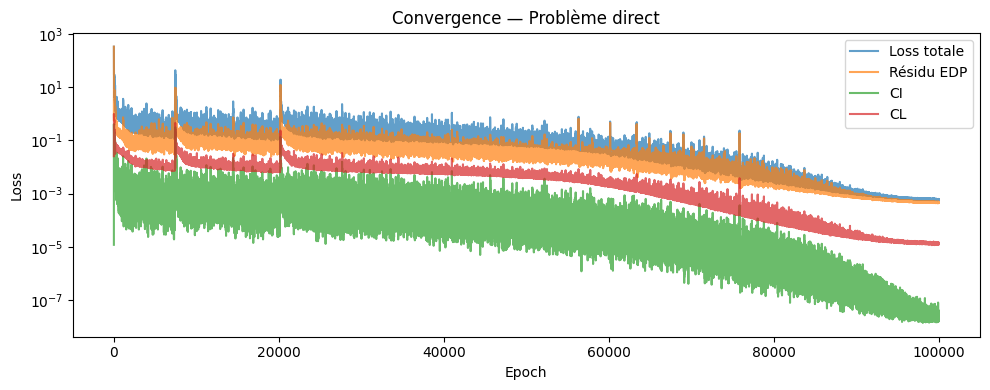

In [57]:
# --- Courbe de convergence ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(history_fwd['loss'], label='Loss totale', alpha=0.7)
ax.semilogy(history_fwd['loss_f'], label='Résidu EDP', alpha=0.7)
ax.semilogy(history_fwd['loss_ic'], label='CI', alpha=0.7)
ax.semilogy(history_fwd['loss_bc'], label='CL', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Convergence — Problème direct')
ax.legend()
plt.tight_layout()
plt.show()

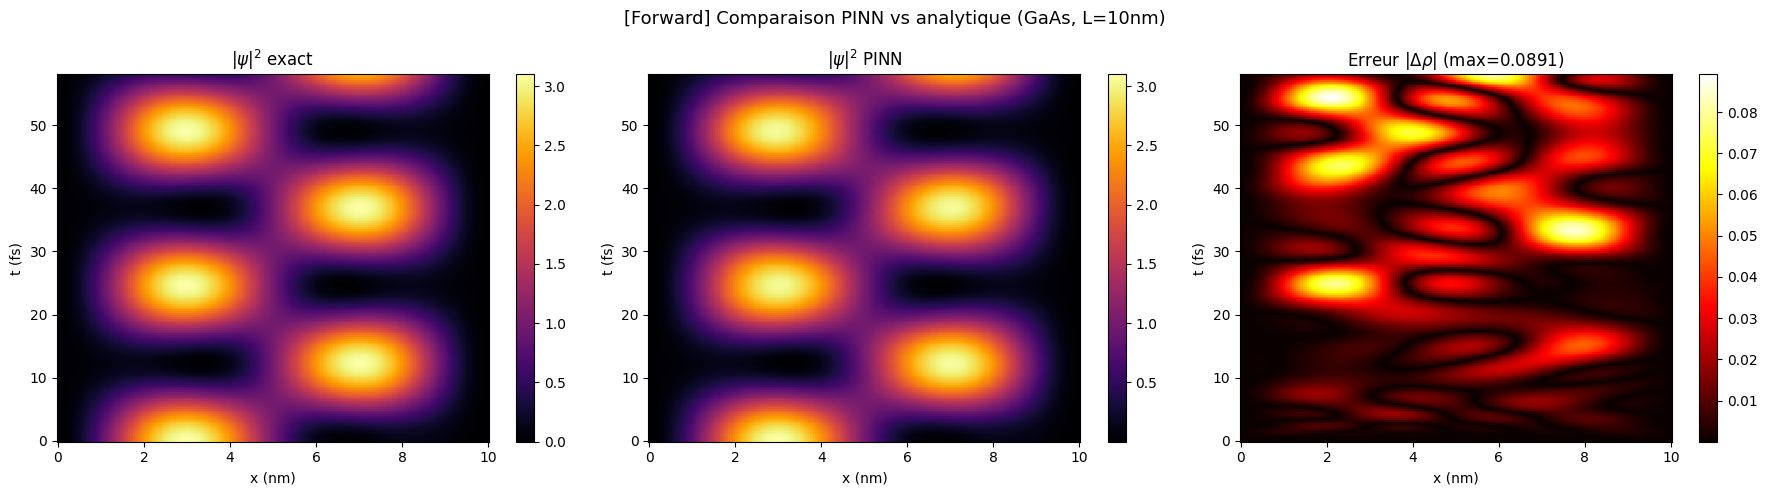

Erreur L² relative sur ψ : 1.4162e+00
Erreur moyenne sur |ψ|²  : 1.6191e-02


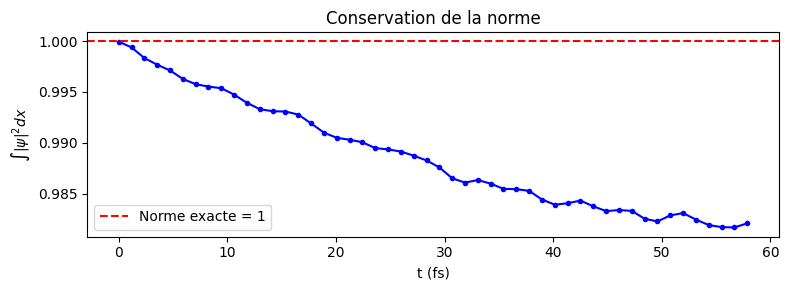

In [58]:
# --- Comparaison PINN vs analytique ---
err_fwd = plot_comparison(net_forward, T_max=T_MAX, title_prefix="[Forward] ")

## 9. Problème inverse : retrouver la masse effective $m^*$

On génère des données synthétiques $|\psi_{\text{data}}|^2$ à partir de la solution exacte (avec bruit), puis on entraîne un PINN avec $\alpha$ comme paramètre apprenable.

Si le PINN retrouve $\hat{\alpha} \approx 1$, cela confirme que $m^* = 0.067\,m_e$.

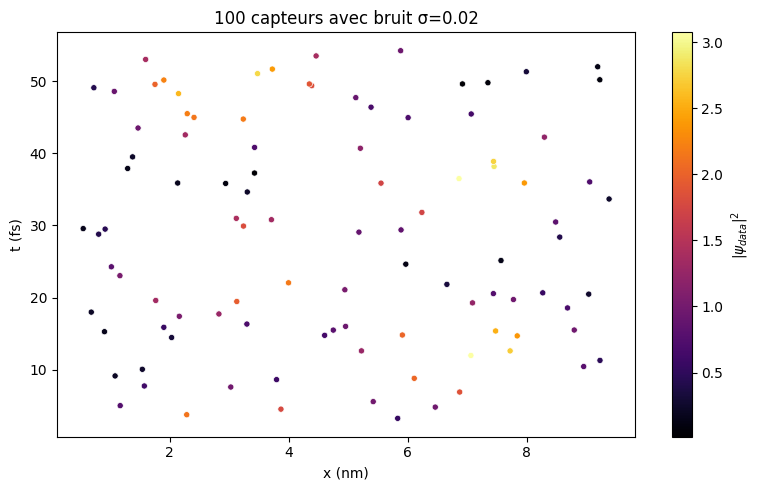

Données : 100 capteurs, bruit σ = 0.02
m*_vrai = 0.067 mₑ → α* = 1.0


In [59]:
# --- Génération des données capteurs ---
N_data = 100  # nombre de points de mesure
sigma_noise = 0.02  # bruit sur |psi|^2

# Positions des capteurs (répartis dans le domaine)
x_data_np = np.random.uniform(0.05, 0.95, N_data)
t_data_np = np.random.uniform(0.05, T_MAX - 0.05, N_data)

# Densité de probabilité exacte + bruit
rho_data_np = np.abs(psi_exact(x_data_np, t_data_np))**2
rho_data_np += np.random.normal(0, sigma_noise, N_data)
rho_data_np = np.clip(rho_data_np, 0, None)  # densité >= 0

# Tenseurs pour le PINN
data_points = {
    'x': torch.tensor(x_data_np, dtype=torch.float32, device=device).reshape(-1, 1),
    't': torch.tensor(t_data_np, dtype=torch.float32, device=device).reshape(-1, 1),
    'rho': torch.tensor(rho_data_np, dtype=torch.float32, device=device).reshape(-1, 1)
}

# Visualisation des capteurs
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(x_data_np * x_0_nm, t_data_np * t_0_fs, c=rho_data_np, cmap='inferno',
                s=20, edgecolors='white', linewidths=0.5)
ax.set_xlabel('x (nm)')
ax.set_ylabel('t (fs)')
ax.set_title(f'{N_data} capteurs avec bruit σ={sigma_noise}')
plt.colorbar(sc, label=r'$|\psi_{data}|^2$')
plt.tight_layout()
plt.show()

print(f"Données : {N_data} capteurs, bruit σ = {sigma_noise}")
print(f"m*_vrai = 0.067 mₑ → α* = 1.0")

In [61]:
alpha_init = 2.0
print(f"Initialisation : α₀ = {alpha_init:.1f} (soit m*₀ = {0.067/alpha_init:.3f} mₑ, erreur ~{abs(alpha_init-1)/1*100:.0f}%)")
print()

net_inverse = SchrodingerNet(hidden_dim=128, n_hidden=5).to(device)
problem_inverse = SchrodingerProblem(net_inverse, alpha=alpha_init, alpha_trainable=True)

history_inv = solve_schrodinger(
    problem_inverse,
    N_iter=50000,
    lr=5e-3,
    N_f=5000,
    N_ic=500,
    N_bc=500,
    T_max=T_MAX,
    lambda_f=1.0,
    lambda_ic=100.0,
    lambda_bc=10.0,
    data_points=data_points,
    lambda_data=10.0,
    pretrain_ic=2000
)

Initialisation : α₀ = 2.0 (soit m*₀ = 0.034 mₑ, erreur ~100%)

Phase 0 : Pré-entraînement CI (2000 itérations)
--------------------------------------------------
  [Pre-IC]    0 | Loss IC: 1.06e+00
  [Pre-IC] 1999 | Loss IC: 7.32e-06

Phase 1 : Entraînement complet (50000 itérations)
--------------------------------------------------
Epoch     0 | Loss: 6.70e+02 | EDP: 6.53e+02 | IC: 1.75e-05 | BC: 5.06e-02 | α: 1.9950
Epoch     1 | Loss: 8.80e+01 | EDP: 4.81e+01 | IC: 2.83e-01 | BC: 2.60e-01 | α: 1.9914
Epoch     2 | Loss: 6.69e+01 | EDP: 1.73e+00 | IC: 5.11e-01 | BC: 3.67e-01 | α: 1.9886
Epoch     3 | Loss: 7.13e+01 | EDP: 6.76e-01 | IC: 5.57e-01 | BC: 4.45e-01 | α: 1.9863
Epoch     4 | Loss: 6.89e+01 | EDP: 6.19e-01 | IC: 5.35e-01 | BC: 5.16e-01 | α: 1.9843
Epoch     5 | Loss: 6.65e+01 | EDP: 8.37e-01 | IC: 5.10e-01 | BC: 5.48e-01 | α: 1.9827
Epoch     6 | Loss: 5.98e+01 | EDP: 1.26e+00 | IC: 4.39e-01 | BC: 5.23e-01 | α: 1.9812
Epoch     7 | Loss: 5.26e+01 | EDP: 1.88e+00 | IC: 3.57

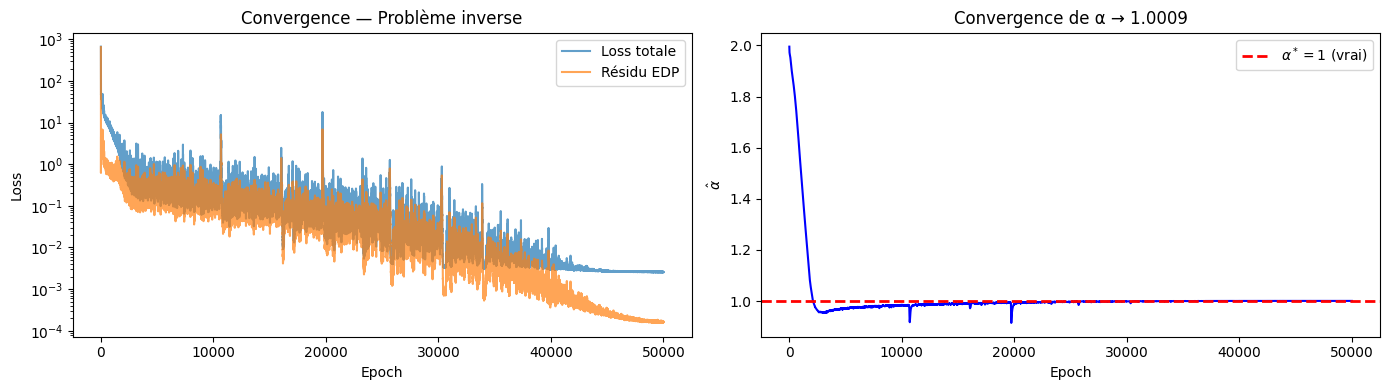

Résultat de l'inversion
α trouvé    : 1.0009 (cible : 1.0000)
m* trouvé   : 0.0669 mₑ (cible : 0.0670 mₑ)
m* trouvé   : 6.097e-32 kg (cible : 6.103e-32 kg)
Erreur rel. : 0.09%


In [62]:
# --- Convergence de alpha ---
alpha_final = history_inv['alpha'][-1]
m_star_found = 0.067 / alpha_final  # en unités de m_e
m_star_found_kg = m_star_found * m_e

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(history_inv['loss'], label='Loss totale', alpha=0.7)
axes[0].semilogy(history_inv['loss_f'], label='Résidu EDP', alpha=0.7)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Convergence — Problème inverse')
axes[0].legend()

axes[1].plot(history_inv['alpha'], 'b-', linewidth=1.5)
axes[1].axhline(1.0, color='r', linestyle='--', linewidth=2, label=r'$\alpha^* = 1$ (vrai)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel(r'$\hat{\alpha}$')
axes[1].set_title(f'Convergence de α → {alpha_final:.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"="*50)
print(f"Résultat de l'inversion")
print(f"="*50)
print(f"α trouvé    : {alpha_final:.4f} (cible : 1.0000)")
print(f"m* trouvé   : {m_star_found:.4f} mₑ (cible : 0.0670 mₑ)")
print(f"m* trouvé   : {m_star_found_kg:.3e} kg (cible : {m_star:.3e} kg)")
print(f"Erreur rel. : {abs(alpha_final - 1.0) / 1.0 * 100:.2f}%")

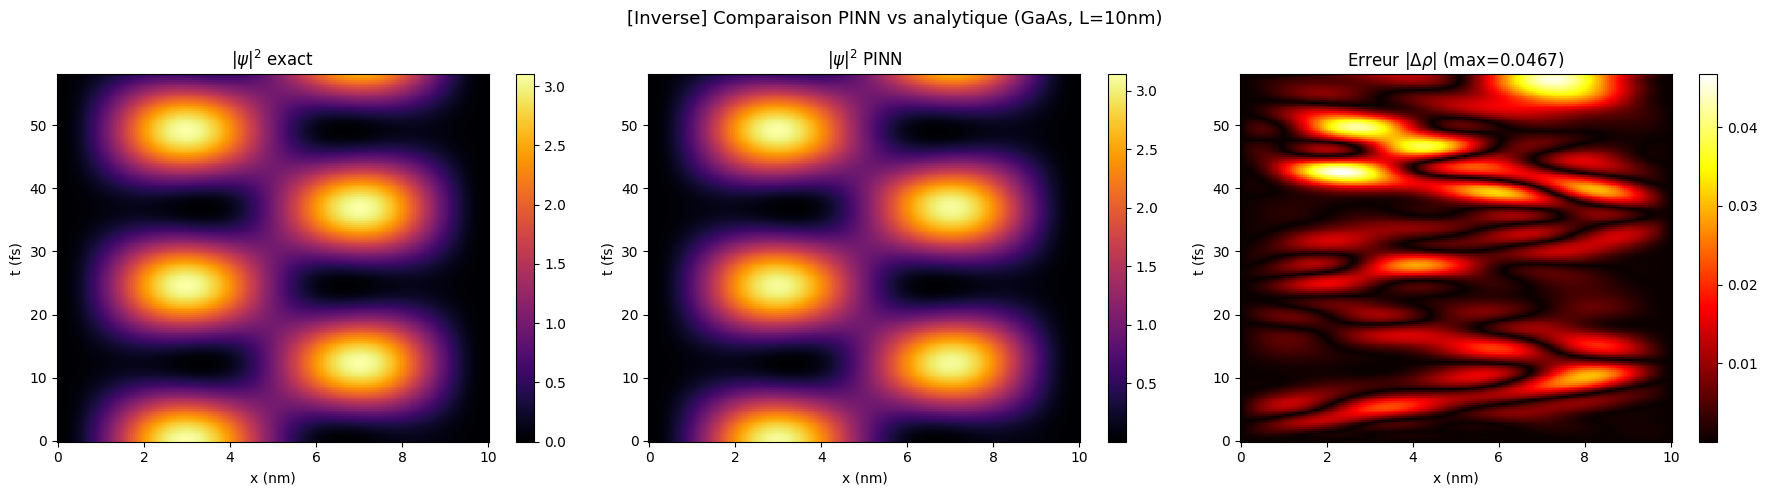

Erreur L² relative sur ψ : 1.4208e+00
Erreur moyenne sur |ψ|²  : 7.3271e-03


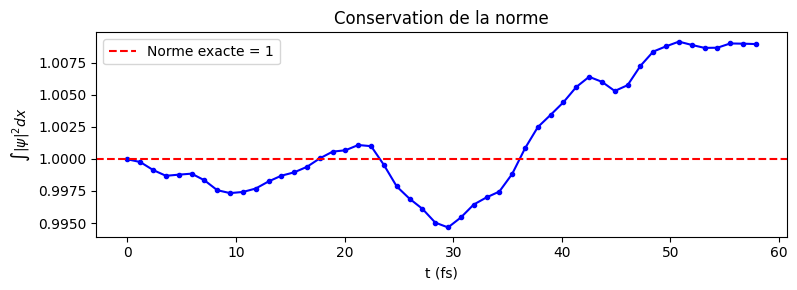

In [63]:
# --- Comparaison PINN inverse vs analytique ---
err_inv = plot_comparison(net_inverse, T_max=T_MAX, title_prefix="[Inverse] ")